# 18. DMR loop sLDSC

Part of the **[Fig. 2 chapter](fig2.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `'ldsc/sumstats_list_75.txt'`  ·  _other_
- `f'{indir}L1color.tsv'`  ·  _metadata: color_


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [1]:
import os
import numpy as np
import pandas as pd
from glob import glob
from scipy.sparse import csr_matrix
from scipy.stats import zscore, wilcoxon
from concurrent.futures import ProcessPoolExecutor, as_completed
from statsmodels.sandbox.stats.multicomp import multipletests as FDR

import anndata
from ALLCools.mcds import MCDS, RegionDS
from ALLCools.clustering import *
from ALLCools.plot import *

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'

import warnings
warnings.filterwarnings("ignore")


/home/zhoujt/.conda/envs/bolero/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/zhoujt/.conda/envs/bolero/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/zhoujt/.conda/envs/bolero/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/zhoujt/.conda/envs/bolero/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/zhoujt/.conda/envs/bolero/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx f

In [2]:
indir = f'{ENTEX_ROOT}/'
outdir = f'{indir}analysis/ldsc/'
coef_file_list = np.sort(glob(f'{outdir}result/*.loopdmr.*.txt'))
print(len(coef_file_list))


75


In [ ]:
tmp = [xx.split('/')[-1].replace('.dmr.slop200.cell_type_results.txt', '') for xx in coef_file_list]
gwas_list = pd.read_csv('ldsc/sumstats_list_75.txt', header=None).reset_index()
gwas_list.index = [xx.split('/')[-1].replace('.sumstats', '') for xx in gwas_list[0]]
gwas_list.loc[~gwas_list.index.isin(tmp)]


In [47]:
filelist = glob(f'{outdir}result/*.loopdmr.*.results')
print(len(filelist))

2612


In [ ]:
# tmp = [xx.split('/')[-1].replace('.loopdmr.*.results', '') for xx in coef_file_list]
# gwas_list = pd.read_csv('ldsc/sumstats_list_75.txt', header=None).reset_index()
# gwas_list.index = [xx.split('/')[-1].replace('.sumstats', '') for xx in gwas_list[0]]
# gwas_list.loc[~gwas_list.index.isin(tmp)]


In [3]:
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
# L1_meta = L1_meta.drop(['c35', 'c36'], axis=0)
L1_meta = L1_meta.drop(['c7'], axis=0)
L1_annot = L1_meta['L1_abbr'].to_dict()
L1_color.update({L1_annot[k]: L1_color[k] for k in L1_annot if k in L1_color})  # also key by name
L1_color = L1_meta['color'].to_dict()


In [4]:
result = {}
for f in coef_file_list:
    tmp = pd.read_csv(f, sep='\t', header=0, index_col=0)
    p = f.split('/')[-1].replace('460K.', '460K_').split('.')[0]
    # result[p] = tmp['Coefficient_P_value']
    fdr = FDR(tmp['Coefficient_P_value'], 0.01, 'fdr_bh')[1]
    result[p] = pd.Series(fdr, index=tmp.index)

result = pd.DataFrame(result)


In [5]:
idx, idy = np.where(result<0.01)
sig1 = pd.Index([f'{yy}.{xx}' for xx,yy in zip(result.index[idx], result.columns[idy])])


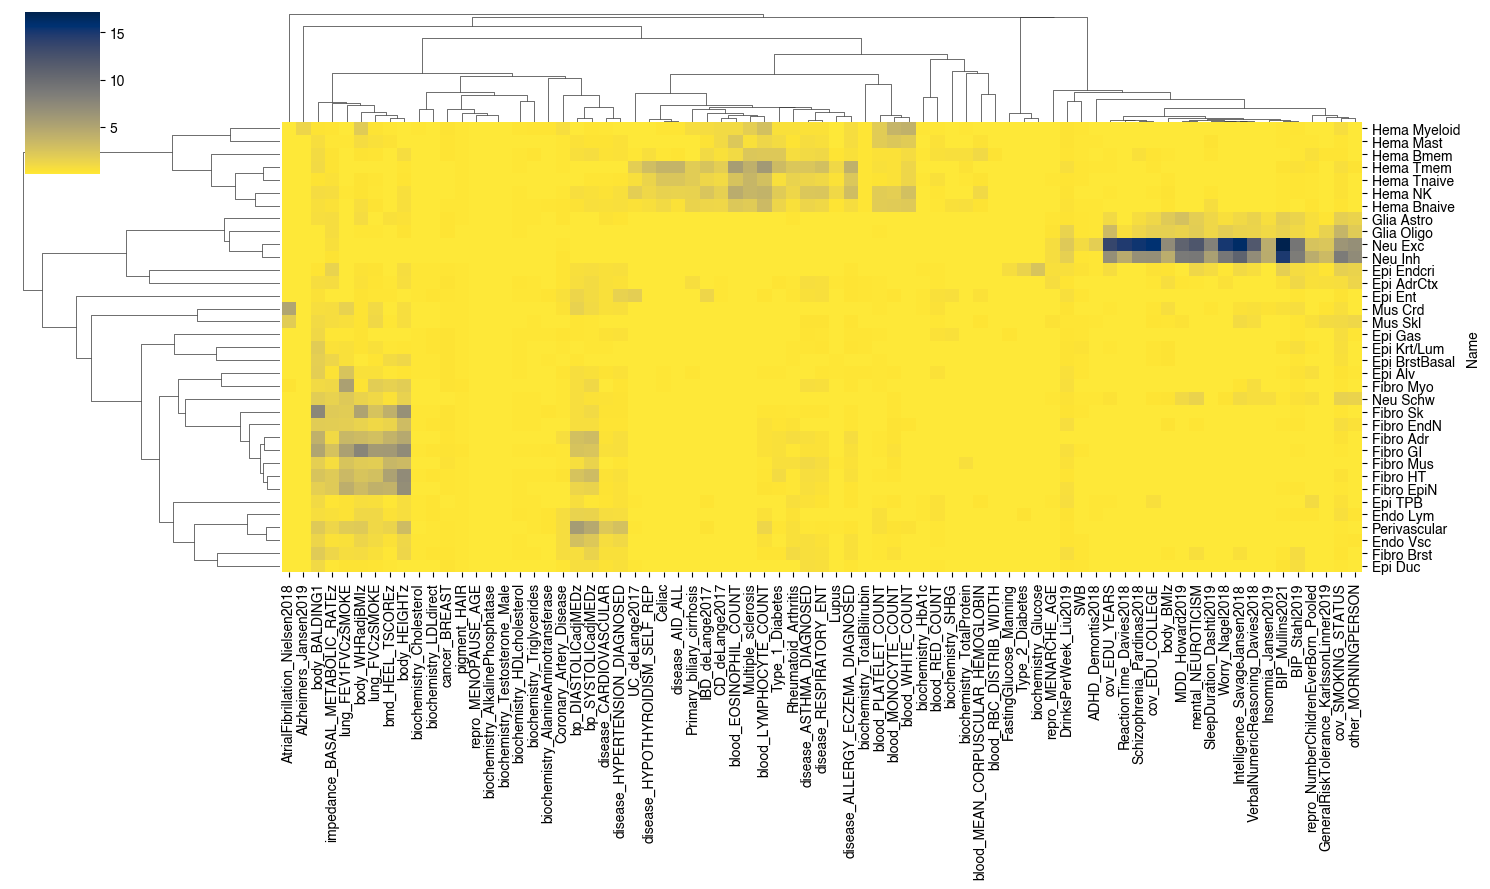

In [6]:
dist = -np.log10(result)
dist.index = result.index.map(L1_meta['L1_abbr'])
dist.columns = dist.columns.str.replace('PASS_','').str.replace('UKB_460K_','')
cg = sns.clustermap(dist, metric='cosine', cmap='cividis_r', 
               xticklabels=1, 
               yticklabels=1, 
               figsize=(15,9))
rorder = dist.index[cg.dendrogram_row.reordered_ind]
corder = dist.columns[cg.dendrogram_col.reordered_ind]


In [7]:
dist = dist.loc[rorder[::-1], :]
bestbulk = np.argmax(dist, axis=0)
bestbulk[dist.max(axis=0)<2] = dist.shape[0]
dist = dist.iloc[:, np.argsort(bestbulk)]
corder = dist.columns.copy()


In [12]:
dist.values.min()

9.376185826931185e-08

135


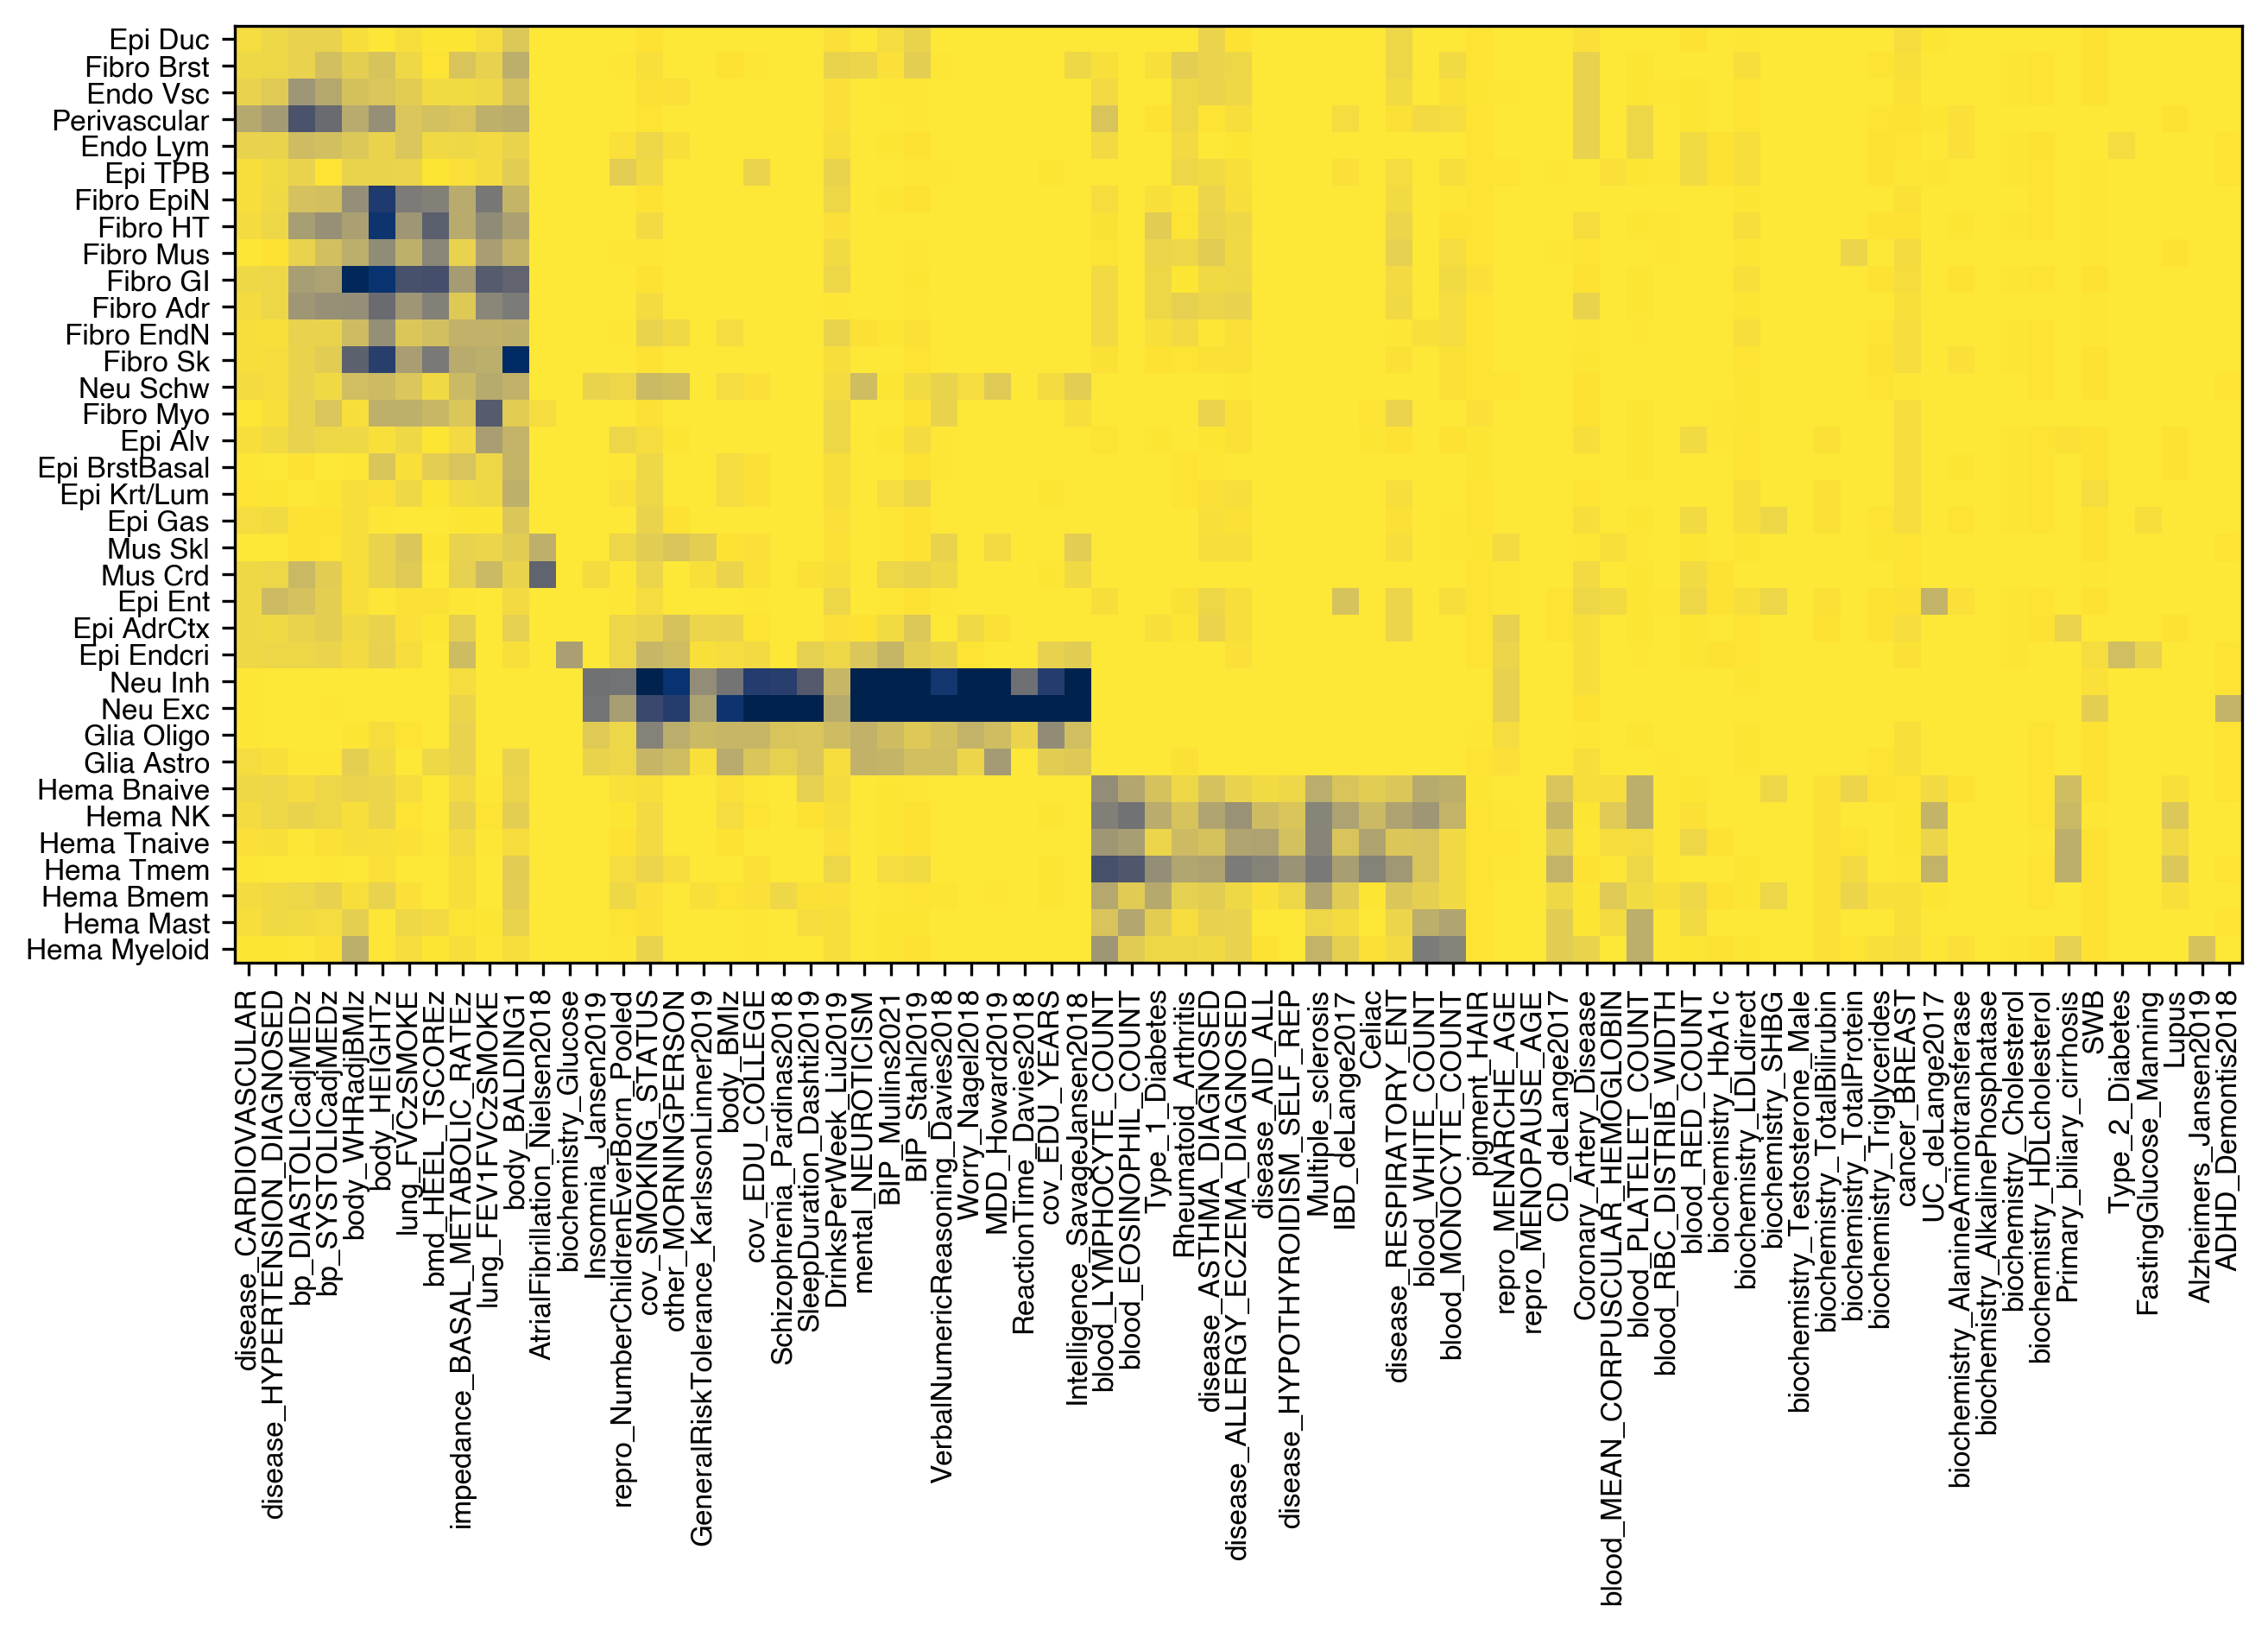

In [13]:
fig, ax = plt.subplots(figsize=(10,6), dpi=300)
ax.imshow(dist, cmap='cividis_r', vmax=8)
xticks = np.arange(dist.shape[1])
ax.set_xticks(xticks)
ax.set_xticklabels(dist.columns[xticks], fontsize=8, rotation=90)
yticks = np.arange(dist.shape[0])
ax.set_yticks(yticks)
ax.set_yticklabels(dist.index[yticks], fontsize=8, rotation=0)
# fig.savefig(f'{outdir}/L1_loopdmr_75GWAS_fdr.pdf', transparent=True)
print(np.sum(dist.values>2))


In [10]:
indir = f'{ENTEX_ROOT}/'
outdir = f'{indir}analysis/ldsc/'
coef_file_list = np.sort(glob(f'{outdir}result/*.dmr.*.txt'))
print(len(coef_file_list))


75


In [11]:
result = {}
for f in coef_file_list:
    tmp = pd.read_csv(f, sep='\t', header=0, index_col=0)
    p = f.split('/')[-1].replace('460K.','460K_').split('.')[0]
    # result[p] = tmp['Coefficient_P_value']
    fdr = FDR(tmp['Coefficient_P_value'], 0.01, 'fdr_bh')[1]
    result[p] = pd.Series(fdr, index=tmp.index)

result = pd.DataFrame(result)


In [12]:
idx, idy = np.where(result<0.01)
sig2 = pd.Index([f'{yy}.{xx}' for xx,yy in zip(result.index[idx], result.columns[idy])])


In [13]:
dist = -np.log10(result)
dist.index = result.index.map(L1_meta['L1_abbr'])
dist.columns = dist.columns.str.replace('PASS_','').str.replace('UKB_460K_','')
# cg = sns.clustermap(dist, metric='cosine', cmap='cividis_r', vmin=2, vmax=8, 
#                xticklabels=1, 
#                yticklabels=1, 
#                figsize=(15,9))
# rorder = dist.index[cg.dendrogram_row.reordered_ind]
# corder = dist.columns[cg.dendrogram_col.reordered_ind]


In [14]:
# dist = dist.loc[rorder[::-1], :]
# bestbulk = np.argmax(dist, axis=0)
# bestbulk[dist.max(axis=0)<2] = dist.shape[0]
# dist = dist.iloc[:, np.argsort(bestbulk)]
dist = dist.loc[rorder[::-1], corder]


101


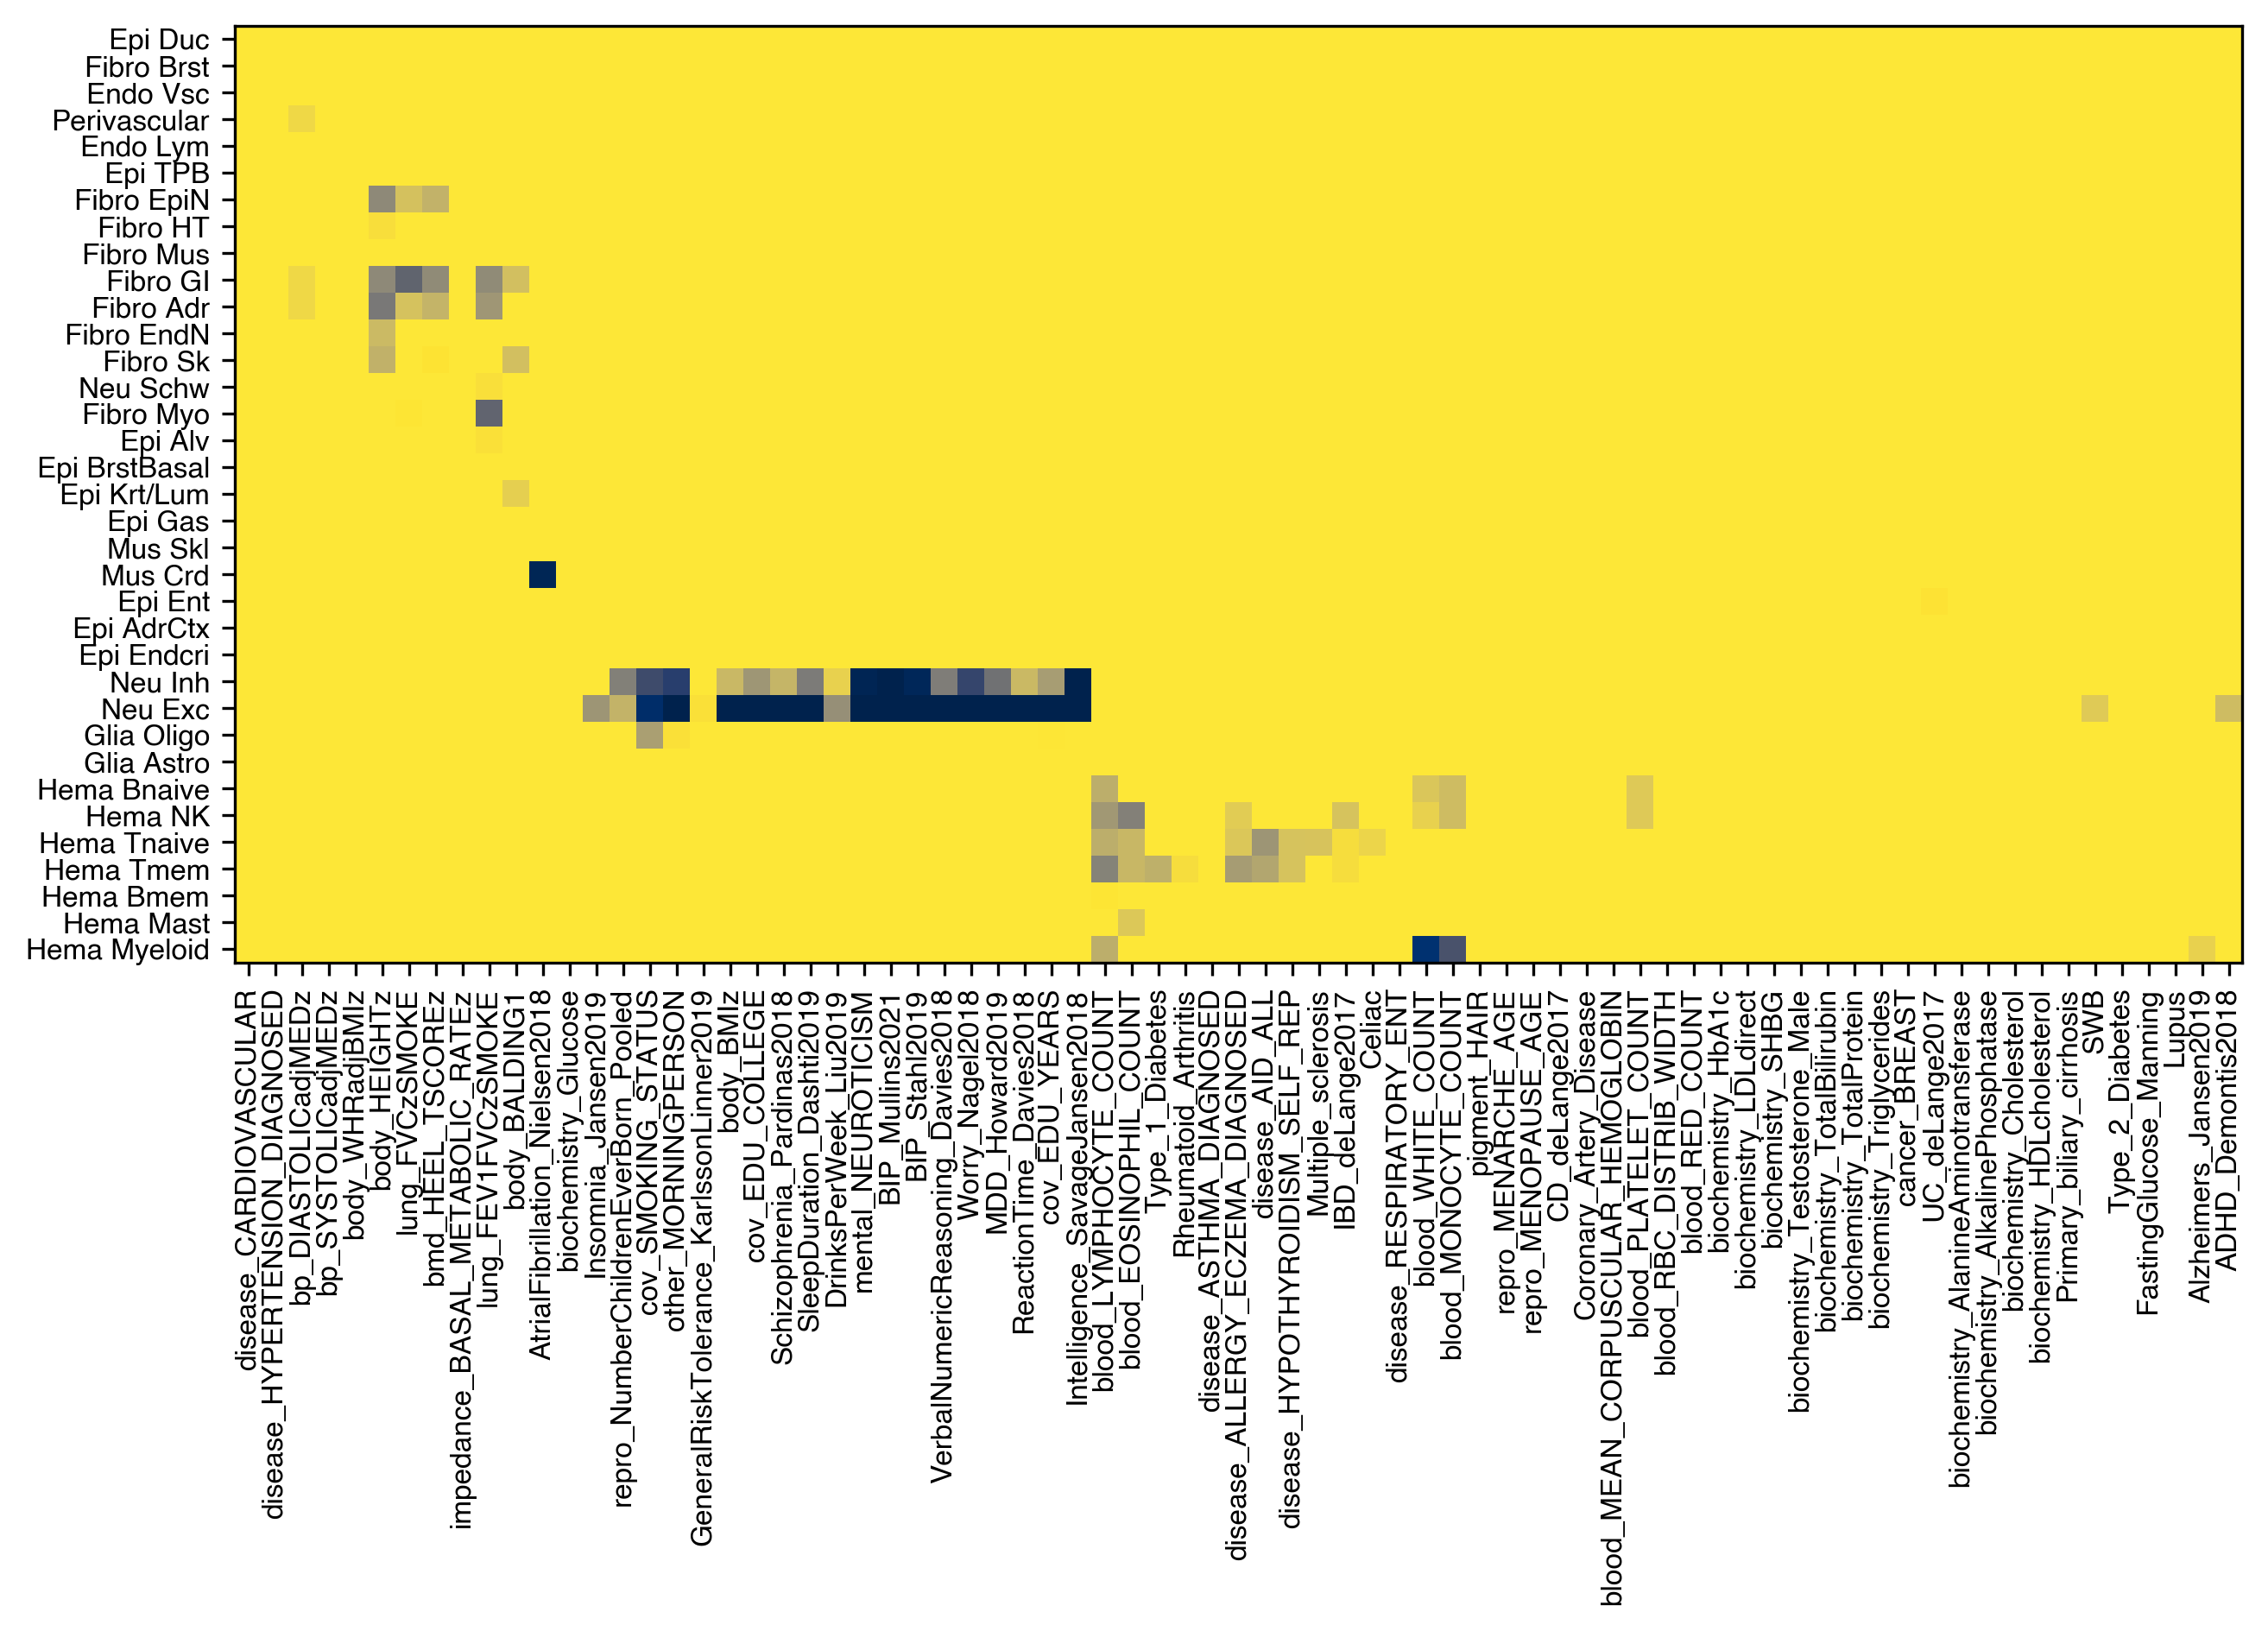

In [15]:
fig, ax = plt.subplots(figsize=(10,6), dpi=300)
ax.imshow(dist, cmap='cividis_r', vmin=2, vmax=8)
xticks = np.arange(dist.shape[1])
ax.set_xticks(xticks)
ax.set_xticklabels(dist.columns[xticks], fontsize=8, rotation=90)
yticks = np.arange(dist.shape[0])
ax.set_yticks(yticks)
ax.set_yticklabels(dist.index[yticks], fontsize=8, rotation=0)
fig.savefig(f'{outdir}/L1_dmr_75GWAS_fdr.pdf', transparent=True)
print(np.sum(dist.values>2))

In [18]:
sig = sig1.union(sig2).str.replace('460K_', '460K.')
print(len(sig))


149


In [74]:
stats1 = {}
for xx in sig:
    f = f'{outdir}result/{xx}.loopdmr.slop200.results'
    if os.path.isfile(f):
        tmp = pd.read_csv(f, header=0, index_col=0, sep='\t')
        stats1[xx] = tmp.loc['L2_0']

stats1 = pd.DataFrame(stats1)


In [75]:
stats2 = {}
for xx in sig:
    f = f'{outdir}result/{xx}.dmr.slop200.results'
    if os.path.isfile(f):
        tmp = pd.read_csv(f, header=0, index_col=0, sep='\t')
        stats2[xx] = tmp.loc['L2_0']

stats2 = pd.DataFrame(stats2)


In [76]:
selp = stats1.columns.intersection(stats2.columns)
print(len(selp))

149


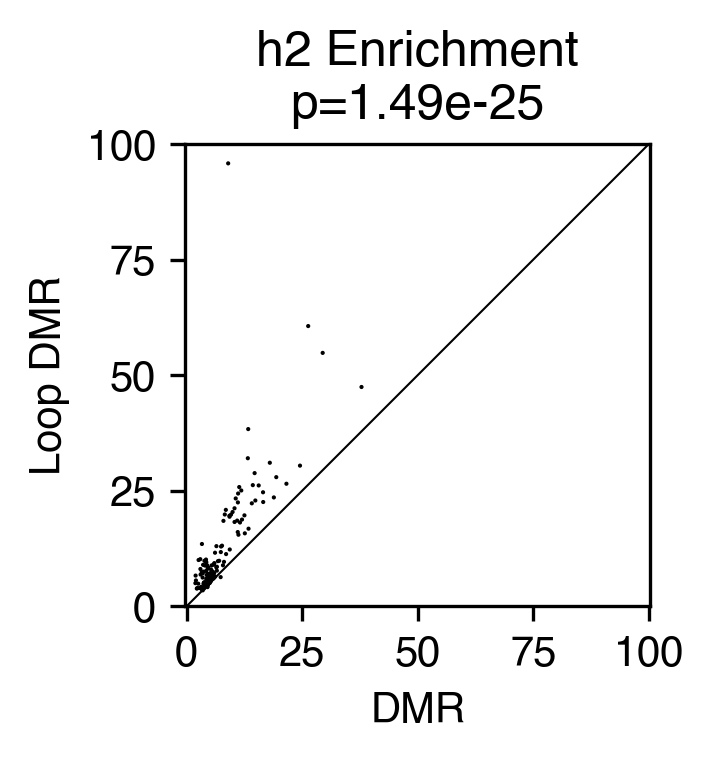

In [77]:
fig, ax = plt.subplots(figsize=(2,2), dpi=300)
ax.axis('equal')
xx = stats2.loc['Enrichment', selp]
yy = stats1.loc['Enrichment', selp]
ax.scatter(x=xx, y=yy, s=1, edgecolor='none', c='k')
ax.plot([0, 100], [0, 100], linewidth=0.5, color='k')
ax.set_xticks(np.arange(0,101,25))
ax.set_yticks(np.arange(0,101,25))
ax.set_xlim([0, 100])
ax.set_ylim([0, 100])
ax.set_xlabel('DMR')
ax.set_ylabel('Loop DMR')
ax.set_title(f'h2 Enrichment\np={wilcoxon(xx,yy)[1]:.2e}')
fig.savefig(f'{outdir}/L1_h2enrich_dmr_loopdmr_75GWAS.pdf', transparent=True)



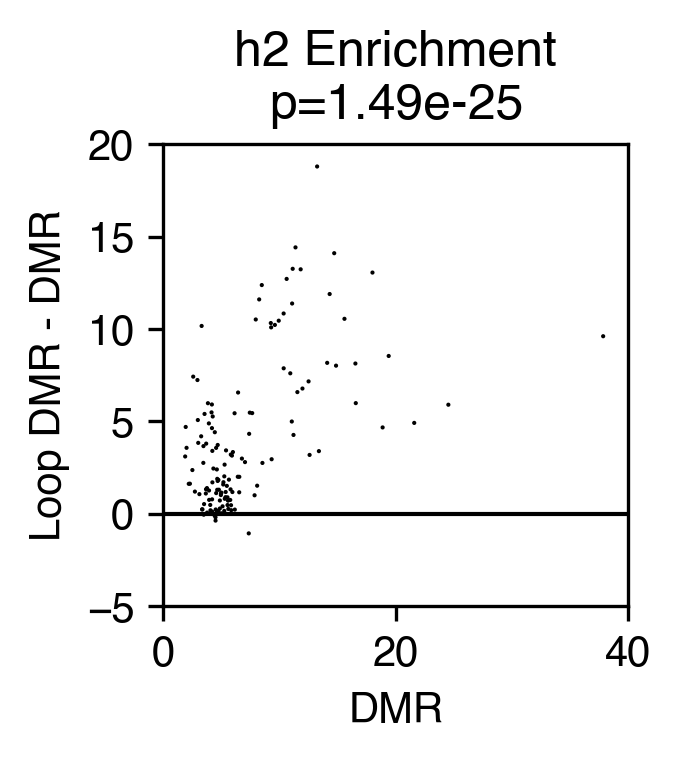

In [78]:
fig, ax = plt.subplots(figsize=(2,2), dpi=300)
xx = stats2.loc['Enrichment', selp]
yy = stats1.loc['Enrichment', selp]
ax.scatter(x=xx, y=yy-xx, s=1, edgecolor='none', c='k')
ax.plot([0, 100], [0, 0], linewidth=1, color='k')
# ax.set_xticks(np.arange(0,101,25))
# ax.set_yticks(np.arange(0,101,25))
ax.set_xlim([0, 40])
ax.set_ylim([-5, 20])
ax.set_xlabel('DMR')
ax.set_ylabel('Loop DMR - DMR')
ax.set_title(f'h2 Enrichment\np={wilcoxon(xx,yy)[1]:.2e}')
fig.savefig(f'{outdir}/L1_h2enrich_dmr_diff_75GWAS.pdf', transparent=True)
